In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import torch

In [2]:
X = np.load('data_window_10s.npy')
y = np.load('label_window_10s.npy')
y1 = np.load('label_window_1_10s.npy')
print(X[:, :, 0].shape)
#X = X[:10000, :, 0]
X = X[:, :, 0]
print(X.shape)
#y = y[:10000]
print(y.shape)

(88649, 240)
(88649, 240)
(88649,)


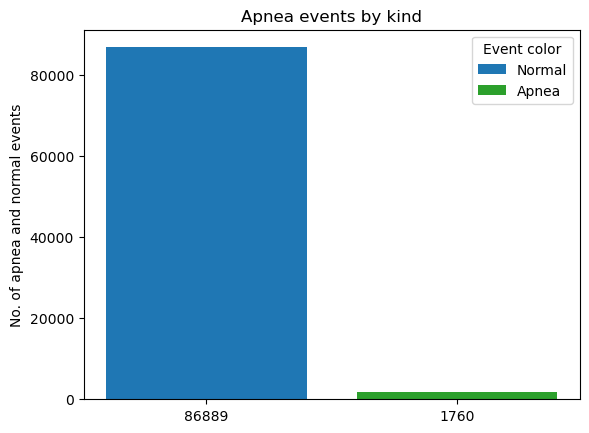

In [3]:
#counting the occurrence of a certain class in y
unique, counts = np.unique(y, return_counts=True)
D=dict(zip(unique, counts))
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
bar_labels = ['Normal', 'Apnea']
bars=list(D.values())
x_pos = (np.arange(len(bars)))
bar_colors = ['tab:blue', 'tab:green']
ax.bar(range(len(D)), bars, align='center',label=bar_labels, color=bar_colors )
ax.set_ylabel('No. of apnea and normal events')
ax.set_title('Apnea events by kind')
ax.legend(title='Event color')
# Create names on the x-axis
plt.xticks(x_pos, bars)
plt.show()

In [4]:
vals_dict = {}
for i in y:
    if i in vals_dict.keys():
        vals_dict[i] += 1
    else:
        vals_dict[i] = 1
total = sum(vals_dict.values())
print(vals_dict)
# Formula used - Naive method where
# weight = 1 - (no. of samples present / total no. of samples)
# So more the samples, lower the weight
weight_dict = {int(k): (1 - (v / total)) for k, v in vals_dict.items()}

print(weight_dict)

{np.int64(0): 86889, np.int64(1): 1760}
{0: 0.019853579848616465, 1: 0.9801464201513835}


In [5]:
vals_dict1 = {}
for i in y1:
    if i in vals_dict1.keys():
        vals_dict1[i] += 1
    else:
        vals_dict1[i] = 1
total = sum(vals_dict1.values())
print(vals_dict1)

# Formula used - Naive method where
# weight = 1 - (no. of samples present / total no. of samples)
# So more the samples, lower the weight
weight_dict1 = {int(k): (1 - (v / total)) for k, v in vals_dict1.items()}

print(weight_dict1)

{np.int64(0): 85767, np.int64(1): 2882}
{0: 0.03251023700210942, 1: 0.9674897629978906}


In [6]:
x_train, x_test, y_train, y_test =train_test_split(
    X, y, test_size=0.2, #shuffle=True #random_state=42, shuffle=True
)
#y_train = np.asarray(y_train).astype(np.float32).reshape(-1, 1)

#y_test = np.asarray(y_test).astype(np.float32).reshape(-1, 1)
x_train = torch.tensor(x_train, dtype=torch.float)
x_test = torch.tensor(x_test, dtype=torch.float)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
print('Test size', x_test.size())
print(y_test.size())

Test size torch.Size([17730, 240])
torch.Size([17730])


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransformerBlock(nn.Module):
    def __init__(self, d_model, head_size, num_heads, ff_dim, dropout):
        super().__init__()
        # In PyTorch embed_dim = d_model
        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)

        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.ffn = nn.Sequential(
            nn.Conv1d(d_model, ff_dim, kernel_size=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(ff_dim, d_model, kernel_size=1)
        )
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # Normalization + Attention + Residual
        res = x
        x = self.layernorm1(x)
        attn_out, _ = self.mha(x, x, x)
        x = res + self.dropout1(attn_out)

        # Feed Forward + Residual
        res = x
        x = self.layernorm2(x)
        x = x.transpose(1, 2)
        x = self.ffn(x)
        x = x.transpose(1, 2)
        return res + self.dropout2(x)

class CustomAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Architettura basata sul paper (132 -> 64 -> 1)
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 132, kernel_size=7, padding=3, stride=2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv1d(132, 64, kernel_size=7, padding=3, stride=2),
            nn.ReLU()
        )

        
        # Upsampling per tornare alla lunghezza originale
        self.decoder = nn.ConvTranspose1d(64, 1, kernel_size=7, padding=3, stride=4, output_padding=3)

    def forward(self, x):
        # x: (batch, 1, seq_len)
        return self.decoder(self.encoder(x))
    

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Primo strato: da 1 canale SpO2 a 132 feature
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=132, kernel_size=7, padding=3, stride=2)
        self.dropout = nn.Dropout(p=0.1)
        
        # SECONDO STRATO (Qui era l'errore): deve accettare 132 canali!
        self.conv2 = nn.Conv1d(in_channels=132, out_channels=64, kernel_size=7, padding=3, stride=2)
        
        # Strato di ricostruzione (Decoder)
        # Riporta a 1 canale per sommarlo all'input originale come Positional Encoding
        self.decoder = nn.ConvTranspose1d(in_channels=64, out_channels=1, kernel_size=7, padding=3, stride=4, output_padding=3)

    def forward(self, x):
        # x shape: (batch, 1, 80)
        #print('x', x.size())
        x_enc = F.relu(self.conv1(x))
        x_enc = self.dropout(x_enc)
        x_enc = F.relu(self.conv2(x_enc))
        
        # Ricostruzione
        pos_encoding = self.decoder(x_enc)
        return pos_encoding
    
class ApneaTransformer(nn.Module):
    def __init__(self, n_classes, head_size, num_heads, ff_dim, num_blocks, mlp_units, dropout, mlp_dropout):
        super().__init__()

        # 1. AutoEncoder (Generatore di Positional Embedding)
        self.auto_pe = AutoEncoder()

        # 2. Input Projection
        # Trasformiamo l'input (1 canale) nella dimensione d_model del Transformer
        self.d_model = head_size * num_heads
        self.input_projection = nn.Linear(1, self.d_model)

        # 3. Transformer Encoder Blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(self.d_model, head_size, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])

        # 4. MLP Head
        layers = []
        curr_in = self.d_model
        for dim in mlp_units:
            layers.append(nn.Linear(curr_in, dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(mlp_dropout))
            curr_in = dim

        self.mlp_head = nn.Sequential(*layers)
        self.classifier = nn.Linear(curr_in, n_classes)

    def forward(self, x):
        # x: (batch, 1, seq_len)

        # LOGICA PAPER: Sommiamo l'input originale al PE generato dall'AutoEncoder
        pe = self.auto_pe(x)
        x_combined = x + pe # Questa è la somma data-driven

        # Trasponiamo per il Transformer: (batch, seq, feat)
        x_combined = x_combined.transpose(1, 2)
        x_projected = self.input_projection(x_combined)

        # Blocchi Transformer
        for block in self.transformer_blocks:
            x_projected = block(x_projected)

        # Global Average Pooling (Lungo la dimensione temporale)
        x_pooled = x_projected.mean(dim=1)

        # MLP Head
        x_mlp = self.mlp_head(x_pooled)
        return self.classifier(x_mlp)

In [8]:
device='cuda'
model = ApneaTransformer(
    n_classes=2,
    head_size=32, #256,
    num_heads=4,
    ff_dim=128, #4,
    num_blocks=4, #6,
    mlp_units=[128], #[256],
    dropout=0.2, #0.1,
    mlp_dropout=0.3 #0.2
).to(device)

In [9]:
import torch.optim as optim
device = 'cpu'
# Parametri presi dal tuo codice Keras
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.0001)
# weight_dict deve essere un tensore con i pesi calcolati
weights = torch.tensor([weight_dict[0], weight_dict[1]], dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss() #weight=weights)
import torch
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

class_counts = np.bincount(y_train)  #coutn occurences of each class
class_weights = 1./ class_counts
weights = class_weights[y_train]  #assign weight to each sample

#create a sampler using these weights (imbalances dataset)
sampler = WeightedRandomSampler(weights, num_samples=len(y_train), replacement=True)



# Prepariamo i dati
train_ds = TensorDataset(
    torch.tensor(x_train).float(), 
    torch.tensor(y_train).long() # <-- Corretto se y_train è 1D
)
train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler), #shuffle=True)

# Scheduler (equivalente alla tua funzione scheduler)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9048) # exp(-0.1) ≈ 0.9048

best_val_loss = float('inf')
patience = 10
trigger_times = 0

state_dict = torch.load("autoenc_150ep_fulldata_10s_script2.pth", weights_only=True)
model.load_state_dict(state_dict)

""" for epoch in range(30):
    print('Epoch', epoch)
    model.train()
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.unsqueeze(1)
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # Forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Step dello scheduler dopo l'epoca 10 (come nel tuo codice)
    if epoch >= 10:
        scheduler.step()
    print('loss', loss.item()/len(train_loader))

    # # --- LOGICA VALIDAZIONE & EARLY STOPPING ---
    # model.eval()
    # val_loss = calculate_val_loss() # Funzione helper da definire

    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     torch.save(model.state_dict(), "training_2/cp.ckpt")
    #     trigger_times = 0
    # else:
    #     trigger_times += 1
    #     if trigger_times >= patience:
    #         print("Early stopping!")
    #         break

torch.save(model.state_dict(), "autoenc_50ep_fulldata.pth") """

/tmp/ipykernel_846/3396052708.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(x_train).float(),
/tmp/ipykernel_846/3396052708.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train).long() # <-- Corretto se y_train è 1D


' for epoch in range(30):\n    print(\'Epoch\', epoch)\n    model.train()\n    for batch_x, batch_y in train_loader:\n        batch_x = batch_x.unsqueeze(1)\n        batch_x, batch_y = batch_x.to(device), batch_y.to(device)\n\n        # Forward pass\n        outputs = model(batch_x)\n        loss = criterion(outputs, batch_y)\n\n        # Backward pass\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n    # Step dello scheduler dopo l\'epoca 10 (come nel tuo codice)\n    if epoch >= 10:\n        scheduler.step()\n    print(\'loss\', loss.item()/len(train_loader))\n\n    # # --- LOGICA VALIDAZIONE & EARLY STOPPING ---\n    # model.eval()\n    # val_loss = calculate_val_loss() # Funzione helper da definire\n\n    # if val_loss < best_val_loss:\n    #     best_val_loss = val_loss\n    #     torch.save(model.state_dict(), "training_2/cp.ckpt")\n    #     trigger_times = 0\n    # else:\n    #     trigger_times += 1\n    #     if trigger_times >= patience:\

In [15]:
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score, BinaryAUROC

# Inizializzazione
metric_acc = BinaryAccuracy().to(device)
metric_f1 = BinaryF1Score().to(device)
metric_auc = BinaryAUROC().to(device)

# Durante la valutazione:
with torch.no_grad():
    x_test = x_test.unsqueeze(1)
    preds = model(x_test)
    # Calcolo
    acc = metric_acc(preds.argmax(dim=1), y_test)
    f1 = metric_f1(preds.argmax(dim=1), y_test)
    auc = metric_auc(preds[:, 1], y_test)

In [16]:
print(acc)
print(f1)
print(auc)

tensor(0.9870)
tensor(0.)
tensor(0.5000)


In [17]:
torch.save(model.state_dict(), "autoenc_50ep.pth")

Loss: 0.0646
accuracy: 0.9900
auc: 0.9916
f1_score: 0.7264
precision: 0.7966
recall: 0.6676
specificity: 0.9965
Validation Accuracy: 0.99
Best threshold based on F1-score: 0.0208
Optimal threshold: 0.0208

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.99      0.99     17378
       Apnea       0.72      0.79      0.75       352

    accuracy                           0.99     17730
   macro avg       0.86      0.89      0.87     17730
weighted avg       0.99      0.99      0.99     17730


--- Confusion Matrix ---
[[17271   107]
 [   74   278]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9938
Negative Predictive Value (NPV): 0.9957
Sensitivity (Recall/TPR): 0.7898
Precision (PPV): 0.7221
Accuracy: 0.9898
F1 Score: 0.7544

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9916
Precision-Recall AUC Score: 0.8189


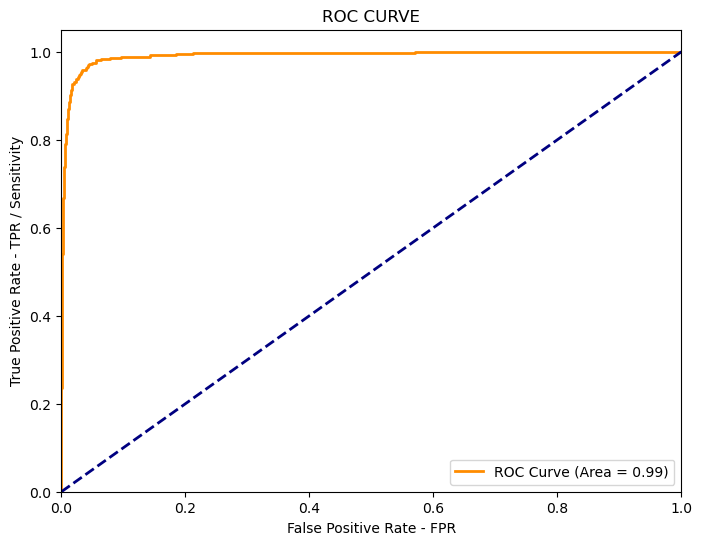

In [12]:
import sys, os
notebook_dir = os.getcwd()
parent_dir = os.path.join(notebook_dir, '..')
sys.path.append(parent_dir)
from aether.utils_rnn import find_best_threshold, calculate_metrics
from torch.utils.data import DataLoader
from torchmetrics import MetricCollection, Accuracy, F1Score, AUROC, Precision, Recall, Specificity
from sklearn.metrics import accuracy_score

# Inizializziamo le metriche (assumendo classificazione binaria come nel tuo esempio)
metrics = MetricCollection({
    'accuracy': Accuracy(task="binary"),
    'f1_score': F1Score(task="binary"),
    'auc': AUROC(task="binary"),
    'precision': Precision(task="binary"),
    'recall': Recall(task="binary"),
    'specificity': Specificity(task="binary")
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
metrics.to(device)


test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64)

def evaluate_pytorch(model, test_loader, criterion):
    model.eval() # Imposta il modello in modalità valutazione
    metrics.reset()
    running_loss = 0.0

    with torch.no_grad(): # Disabilita il calcolo dei gradienti (risparmia memoria)
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            x_batch = x_batch.unsqueeze(1)
            # Forward pass
            outputs = model(x_batch)

            # Se il modello restituisce logits, applichiamo sigmoid per le metriche
            #probs = torch.sigmoid(outputs)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            # Calcolo Loss
            loss = criterion(outputs, y_batch.long())
            running_loss += loss.item()

            # Aggiornamento metriche
            metrics.update(probs, y_batch.int())

    # Calcolo finale
    total_loss = running_loss / len(test_loader)
    final_metrics = metrics.compute()
    
    print(f"Loss: {total_loss:.4f}")
    for key, value in final_metrics.items():
        print(f"{key}: {value.item():.4f}")

# Esecuzione
criterion = torch.nn.CrossEntropyLoss()
evaluate_pytorch(model.to(device), test_loader, criterion)






def evaluate_model(model, data_loader, device):
    """
    Function performing the model's forward pass to gain the predictions,
    class probabilities and ordered real labels.

    :param nn.Module model: input model
    :param DataLoader data_loader: data loader we are considering for evaluation
    :param torch.device device: device

    :return: accurcay of the model, predictions, related class probabilities and 
             ordered labels
    :rtype: float, np.array, np.array, np.array
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            X_batch = X_batch.unsqueeze(1) # (batch, seq_len) -> (batch, seq_len, 1)

            outputs = model(X_batch)
            outs = torch.softmax(outputs, dim=1)[:, 1]
            predictions = (outs > 0.5).long()

            all_preds.append(predictions.cpu())
            all_probs.append(outs.cpu())
            all_labels.append(y_batch.cpu())

    all_preds_np = torch.cat(all_preds, dim=0).numpy()
    all_probs_np = torch.cat(all_probs, dim=0).numpy()
    all_labels_np = torch.cat(all_labels, dim=0).numpy() 

    acc = accuracy_score(all_labels_np, all_preds_np)

    return acc, all_preds_np, all_labels_np, all_probs_np




val_accuracy, y_pred, y_true, y_probs = evaluate_model(model, test_loader, device)
print(f"Validation Accuracy: {val_accuracy:.2f}")

lstm_probs_val = np.array(y_probs)

best_thresh = find_best_threshold(np.array(y_true), lstm_probs_val, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (lstm_probs_val >= best_thresh).astype(int)

metrics_dict = calculate_metrics(y_true, y_pred, lstm_probs_val)

## Practical application

In [25]:
X = np.load('data_window_eval.npy')
y = np.load('label_window_eval.npy')
y1 = np.load('label_window_1_eval.npy')
print(X[:, :, 0].shape)
#X = X[:10000, :, 0]
X = X[:, :, 0]
print(X.shape)
#y = y[:10000]
print(y.shape)

(1399, 240)
(1399, 240)
(1399,)


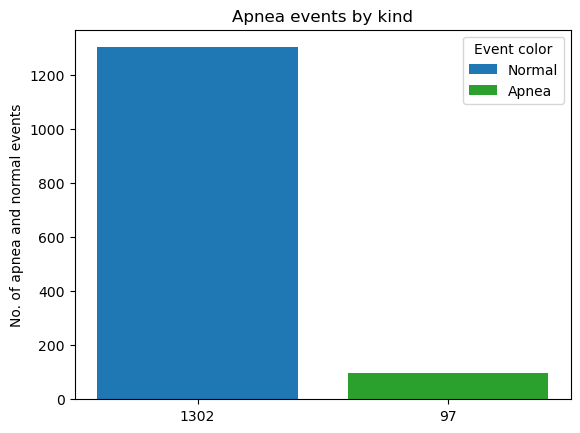

In [26]:
#counting the occurrence of a certain class in y
unique, counts = np.unique(y, return_counts=True)
D=dict(zip(unique, counts))
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
bar_labels = ['Normal', 'Apnea']
bars=list(D.values())
x_pos = (np.arange(len(bars)))
bar_colors = ['tab:blue', 'tab:green']
ax.bar(range(len(D)), bars, align='center',label=bar_labels, color=bar_colors )
ax.set_ylabel('No. of apnea and normal events')
ax.set_title('Apnea events by kind')
ax.legend(title='Event color')
# Create names on the x-axis
plt.xticks(x_pos, bars)
plt.show()

In [27]:
model.eval()

nuovi_dati_tensor = torch.tensor(X, dtype=torch.float)

# 5. Esegui la predizione senza calcolare i gradienti (risparmia memoria e va veloce)
with torch.no_grad():
    # Inserisci la dimensione del canale (batch, 1, seq_len) richiesta dal modello
    # Se passi tutto il file insieme:
    input_dati = nuovi_dati_tensor.unsqueeze(1).to(device)
    
    # Forward pass
    outputs = model(input_dati)
    
    # Calcola le probabilità reali usando Softmax lungo le classi
    probabilita = F.softmax(outputs, dim=1)
    
    # Estrai la probabilità specifica per la classe 1 (Apnea)
    prob_apnea = probabilita[:, 1].cpu().numpy()
    
    # 6. Applica la soglia ottima che avevi calcolato (es. 0.3950) invece di quella standard a 0.50
    soglia_ottimale = 0.3950
    predizioni_finali = (prob_apnea >= soglia_ottimale).astype(int)

# 7. Mostra i Risultati dell'output
print("\n=== RISULTATI DEL MODELLO ===")
totale_finestre = len(predizioni_finali)
apnee_rilevate = np.sum(predizioni_finali)

print(f"Totale finestre analizzate (da 5 secondi l'una): {totale_finestre}")
print(f"Eventi di apnea rilevati: {apnee_rilevate} (pari al {(apnee_rilevate/totale_finestre)*100:.2f}% del tempo totale)")

# Stampa i primi 20 risultati come esempio visivo
print("\nEsempio prime 20 finestre analizzate:")
print(f"Predizione (0=Sano, 1=Apnea): {predizioni_finali[:20]}")
print(f"Probabilità effettiva Apnea:  {prob_apnea[:20]}")


=== RISULTATI DEL MODELLO ===
Totale finestre analizzate (da 5 secondi l'una): 1399
Eventi di apnea rilevati: 51 (pari al 3.65% del tempo totale)

Esempio prime 20 finestre analizzate:
Predizione (0=Sano, 1=Apnea): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
Probabilità effettiva Apnea:  [1.9041338e-16 1.0822352e-16 3.5022914e-16 4.1010029e-16 1.9918493e-16
 1.7653272e-16 8.6693412e-17 8.3151180e-17 3.7489919e-16 7.5159568e-16
 2.0789285e-13 6.6412706e-03 4.3916065e-04 9.5235885e-17 1.5301078e-16
 5.7378970e-16 4.6096865e-08 2.6355578e-12 8.7459101e-16 8.2156587e-01]


Best threshold based on F1-score: 0.0003
Optimal threshold: 0.0003

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.97      0.99      0.98      1302
       Apnea       0.80      0.66      0.72        97

    accuracy                           0.96      1399
   macro avg       0.89      0.82      0.85      1399
weighted avg       0.96      0.96      0.96      1399


--- Confusion Matrix ---
[[1286   16]
 [  33   64]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9877
Negative Predictive Value (NPV): 0.9750
Sensitivity (Recall/TPR): 0.6598
Precision (PPV): 0.8000
Accuracy: 0.9650
F1 Score: 0.7232

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9772
Precision-Recall AUC Score: 0.7852


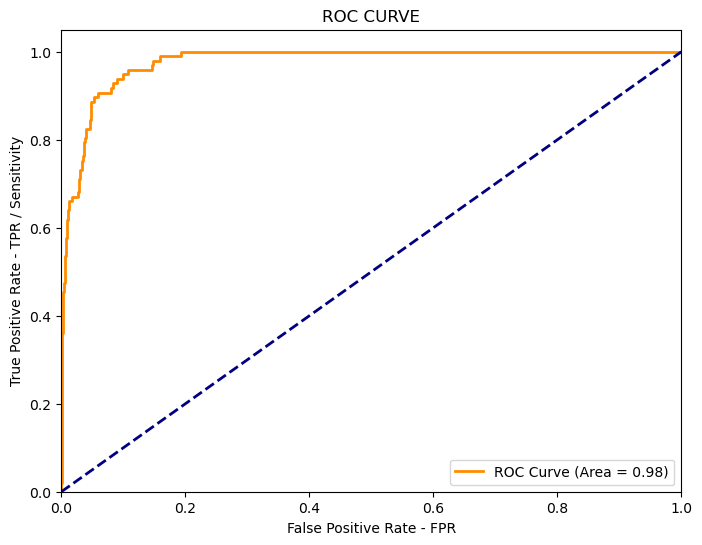

In [28]:
#lstm_probs_val = np.array(probabilita.cpu())

if probabilita.ndim == 2 and probabilita.shape[1] == 2:
    lstm_probs_val = np.array(probabilita.cpu())[:, 1]
else:
    lstm_probs_val = np.array(probabilita.cpu()).ravel()

# Assicurati che anche y sia un array piatto a 1 dimensione
y_true = np.array(y).ravel()

best_thresh = find_best_threshold(y_true, lstm_probs_val, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (lstm_probs_val >= best_thresh).astype(int)

metrics_dict = calculate_metrics(y_true, y_pred, lstm_probs_val)

ANALISI CONFRONTO EVENTI DI APNEA
Totale finestre di Apnea reali nel file: 97
  • APNEE TROVATE (Veri Positivi):  64 (65.98%)
  • APNEE MANCATE (Falsi Negativi): 33 (34.02%) ⚠️
--------------------------------------------------
Totale finestre di Non-Apnea (Sane) reali: 1302
  • Corrette (Veri Negativi):       1286
  • Falsi Allarmi (Falsi Positivi):  16

--- Classication Report Completo ---
              precision    recall  f1-score   support

   Non-Apnea       0.97      0.99      0.98      1302
       Apnea       0.80      0.66      0.72        97

    accuracy                           0.96      1399
   macro avg       0.89      0.82      0.85      1399
weighted avg       0.96      0.96      0.96      1399



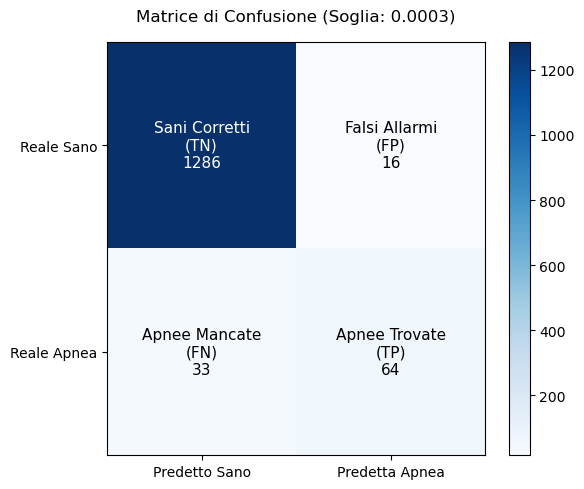

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Applica la soglia ottimale trovata per ottenere le predizioni finali (0 o 1)
# Usiamo il vettore 'lstm_probs_val' (solo colonna 1) estratto al passaggio precedente
predizioni_finali = (lstm_probs_val >= best_thresh).astype(int)

# Assicuriamoci che i target reali siano piatti
y_true_flat = np.array(y).ravel()

# 2. Calcola la Matrice di Confusione scritta
# L'ordine standard di sklearn è: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_true_flat, predizioni_finali).ravel()

# 3. Calcola le percentuali di rilevamento
totale_apnee_reali = tp + fn
totale_sani_reali = tn + fp

percentuale_trovate = (tp / totale_apnee_reali * 100) if totale_apnee_reali > 0 else 0
percentuale_mancate = (fn / totale_apnee_reali * 100) if totale_apnee_reali > 0 else 0

# ==========================================
# REPORT DETTAGLIATO IN ITALIANO
# ==========================================
print("=" * 50)
print("ANALISI CONFRONTO EVENTI DI APNEA")
print("=" * 50)
print(f"Totale finestre di Apnea reali nel file: {totale_apnee_reali}")
print(f"  • APNEE TROVATE (Veri Positivi):  {tp} ({percentuale_trovate:.2f}%)")
print(f"  • APNEE MANCATE (Falsi Negativi): {fn} ({percentuale_mancate:.2f}%) ⚠️")
print("-" * 50)
print(f"Totale finestre di Non-Apnea (Sane) reali: {totale_sani_reali}")
print(f"  • Corrette (Veri Negativi):       {tn}")
print(f"  • Falsi Allarmi (Falsi Positivi):  {fp}")
print("=" * 50)

# Stampa anche il report classico per vedere Precision e Recall aggiornate
print("\n--- Classication Report Completo ---")
print(classification_report(y_true_flat, predizioni_finali, target_names=['Non-Apnea', 'Apnea']))

# ==========================================
# GRAFICO DELLA MATRICE DI CONFUSIONE
# ==========================================
fig, ax = plt.subplots(figsize=(6, 5))
cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Aggiungi i testi dentro i quadrati
testi = [
    [f"Sani Corretti\n(TN)\n{tn}", f"Falsi Allarmi\n(FP)\n{fp}"],
    [f"Apnee Mancate\n(FN)\n{fn}", f"Apnee Trovate\n(TP)\n{tp}"]
]

for i in range(2):
    for j in range(2):
        # Cambia colore del testo in base allo sfondo per renderlo leggibile
        colore_testo = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, testi[i][j], ha="center", va="center", color=colore_testo, fontsize=11)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predetto Sano', 'Predetta Apnea'])
ax.set_yticklabels(['Reale Sano', 'Reale Apnea'])
ax.set_title(f'Matrice di Confusione (Soglia: {best_thresh:.4f})', fontsize=12, pad=15)
plt.colorbar(im)
plt.tight_layout()
plt.show()

=== COORD_TEMPORALI DEGLI ERRORI E SUCCESSI ===

Nel file sono presenti 50 blocchi/eventi di apnea reali:
  • Evento 1: da 55s a 65s (Durata: 10 secondi)
  • Evento 2: da 270s a 285s (Durata: 15 secondi)
  • Evento 3: da 295s a 310s (Durata: 15 secondi)
  • Evento 4: da 330s a 335s (Durata: 5 secondi)
  • Evento 5: da 475s a 485s (Durata: 10 secondi)
  • Evento 6: da 780s a 795s (Durata: 15 secondi)
  • Evento 7: da 1160s a 1165s (Durata: 5 secondi)
  • Evento 8: da 1215s a 1220s (Durata: 5 secondi)
  • Evento 9: da 1255s a 1265s (Durata: 10 secondi)
  • Evento 10: da 1315s a 1330s (Durata: 15 secondi)
  ... e altri 40 eventi.


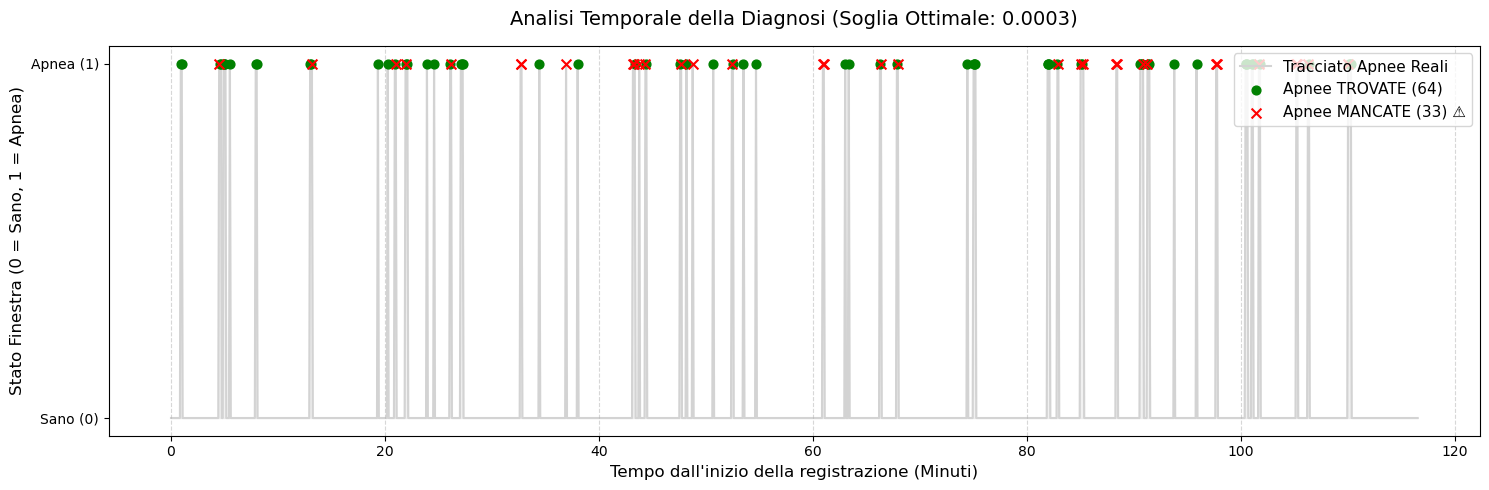

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurazione parametri temporali
DURATA_FINESTRA = 5  # Ogni finestra dura 5 secondi
predizioni_finali = (lstm_probs_val >= best_thresh).astype(int)
y_true_flat = np.array(y).ravel()

print("=== COORD_TEMPORALI DEGLI ERRORI E SUCCESSI ===")

# 2. Funzione helper per unire finestre consecutive in eventi completi
def estrai_intervalli(array_binario, durata_finestra):
    intervalli = []
    in_evento = False
    inizio = 0
    
    for idx, valore in enumerate(array_binario):
        if valore == 1 and not in_evento:
            inizio = idx * durata_finestra
            in_evento = True
        elif valore == 0 and in_evento:
            fine = idx * durata_finestra
            intervalli.append((inizio, fine))
            in_evento = False
            
    if in_evento: # Gestisce l'evento se finisce all'ultima finestra
        intervalli.append((inizio, len(array_binario) * durata_finestra))
    return intervalli

# Calcoliamo gli eventi reali totali
eventi_reali = estrai_intervalli(y_true_flat, DURATA_FINESTRA)

# 3. Identifichiamo le finestre specifiche di successo e di errore
punti_tp = []  # Apnee indovinate
punti_fn = []  # Apnee mancate

for idx in range(len(y_true_flat)):
    tempo_sec = idx * DURATA_FINESTRA
    if y_true_flat[idx] == 1 and predizioni_finali[idx] == 1:
        punti_tp.append(tempo_sec)
    elif y_true_flat[idx] == 1 and predizioni_finali[idx] == 0:
        punti_fn.append(tempo_sec)

# Stampiamo un riassunto degli eventi reali nel tempo
print(f"\nNel file sono presenti {len(eventi_reali)} blocchi/eventi di apnea reali:")
for i, (ini, fine) in enumerate(eventi_reali[:10]):  # Ne mostriamo al massimo 10 per non intasare l'output
    print(f"  • Evento {i+1}: da {ini}s a {fine}s (Durata: {fine-ini} secondi)")
if len(eventi_reali) > 10:
    print(f"  ... e altri {len(eventi_reali) - 10} eventi.")

# =====================================================================
# GRAFICO TEMPORALE DELLE APNEE (Mancate vs Trovate)
# =====================================================================
plt.figure(figsize=(15, 5))

# Creiamo l'asse del tempo continuo (in minuti per facilitare la lettura)
tempo_minuti = (np.arange(len(y_true_flat)) * DURATA_FINESTRA) / 60

# Disegniamo la linea blu delle apnee reali (0 = Sano, 1 = Apnea)
plt.plot(tempo_minuti, y_true_flat, color='lightgray', linestyle='-', label='Tracciato Apnee Reali', zorder=1)
plt.fill_between(tempo_minuti, 0, y_true_flat, color='lightgray', alpha=0.3)

# Convertiamo i secondi in minuti per i punti sul grafico
punti_tp_min = np.array(punti_tp) / 60
punti_fn_min = np.array(punti_fn) / 60

# Evidenziamo dove il modello ha INDOVINATO (Veri Positivi - Verde)
if len(punti_tp_min) > 0:
    plt.scatter(punti_tp_min, np.ones_like(punti_tp_min), color='green', 
                label=f'Apnee TROVATE ({len(punti_tp)})', s=40, marker='o', zorder=3)

# Evidenziamo dove il modello ha MANCATO l'evento (Falsi Negativi - Rosso)
if len(punti_fn_min) > 0:
    plt.scatter(punti_fn_min, np.ones_like(punti_fn_min), color='red', 
                label=f'Apnee MANCATE ({len(punti_fn)}) ⚠️', s=50, marker='x', zorder=4)

# Abbellimento del grafico
plt.title(f"Analisi Temporale della Diagnosi (Soglia Ottimale: {best_thresh:.4f})", fontsize=14, pad=15)
plt.xlabel("Tempo dall'inizio della registrazione (Minuti)", fontsize=12)
plt.ylabel("Stato Finestra (0 = Sano, 1 = Apnea)", fontsize=12)
plt.yticks([0, 1], ['Sano (0)', 'Apnea (1)'])
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()